# Baseline

## Общая инициализация
Нужно выполнить в самом начале независимо от дальнейших действий

### Путь к каталогу, в котором лежит датасет
датасет представлен файлом `train.csv` и папкой `train`

In [ ]:
import os
import random
import time
from enum import Enum
from pathlib import Path
from pprint import pprint
from typing import NoReturn

import librosa
import librosa.feature as F_lib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import Audio
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!unzip -qq"/content/drive/MyDrive/Colab Notebooks/audio_train.zip"

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/train.csv")
local_path = "/content/train"
df["fname"] = df["fname"].apply(lambda x: Path(local_path, x))
df.head(10)

,fname,label
0,/content/train/8bcbcc394ba64fe85ed4.wav,Finger_snapping
1,/content/train/00d77b917e241afa06f1.wav,Squeak
2,/content/train/17bb93b73b8e79234cb3.wav,Electric_piano
3,/content/train/7d5c7a40a936136da55e.wav,Harmonica
4,/content/train/17e0ee7565a33d6c2326.wav,Snare_drum
5,/content/train/2d2900e792da5d4f6ab2.wav,Trumpet
6,/content/train/6464a45df1b76196be09.wav,Computer_keyboard
7,/content/train/b7c35da78543d5f73429.wav,Clarinet
8,/content/train/511d31f5a851cc0dae15.wav,Harmonica
9,/content/train/3496eb9b56346215e4d3.wav,Laughter


#### Спектрограмма

In [ ]:
# spectrogram parameters
sample_rate = 11025

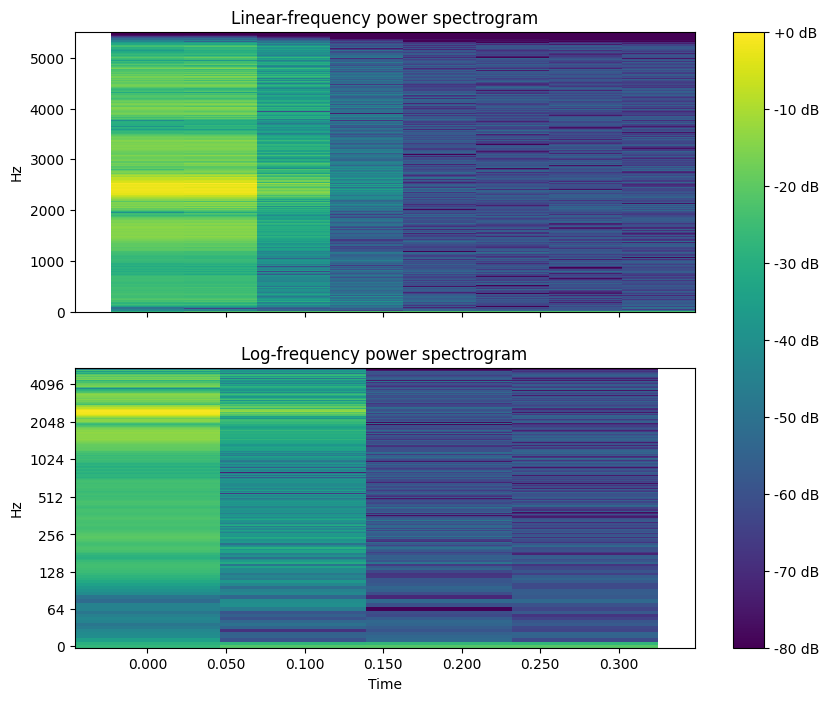

In [ ]:
wav_data, sr = librosa.load(df.loc[0, "fname"], sr=sample_rate)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
cmap = "viridis"

# draw linear-frequency spectrogram
hop_length = 512
wav_data_db = librosa.amplitude_to_db(np.abs(librosa.stft(wav_data, hop_length=hop_length)), ref=np.max)
img1 = librosa.display.specshow(
    wav_data_db,
    sr=sr,
    hop_length=hop_length,
    ax=ax_top,
    x_axis="time",
    y_axis="linear",
    cmap=cmap,
)
ax_top.set(title="Linear-frequency power spectrogram")
ax_top.label_outer()

# draw log-frequency spectrogram
hop_length = 1024
wav_data_db = librosa.amplitude_to_db(np.abs(librosa.stft(wav_data, hop_length=hop_length)), ref=np.max)
img2 = librosa.display.specshow(
    wav_data_db,
    sr=sr,
    hop_length=hop_length,
    ax=ax_bottom,
    x_axis="time",
    y_axis="log",
    cmap=cmap,
)
ax_bottom.set(title="Log-frequency power spectrogram")
ax_bottom.label_outer()

fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.show()

display(Audio(wav_data, rate=sr))

#### Mel-спектрограмма

In [ ]:
# melspectrogram parameters
sample_rate = 11025
n_fft = 1024
overlap = 4
hop_length = n_fft // overlap
n_mels = 64

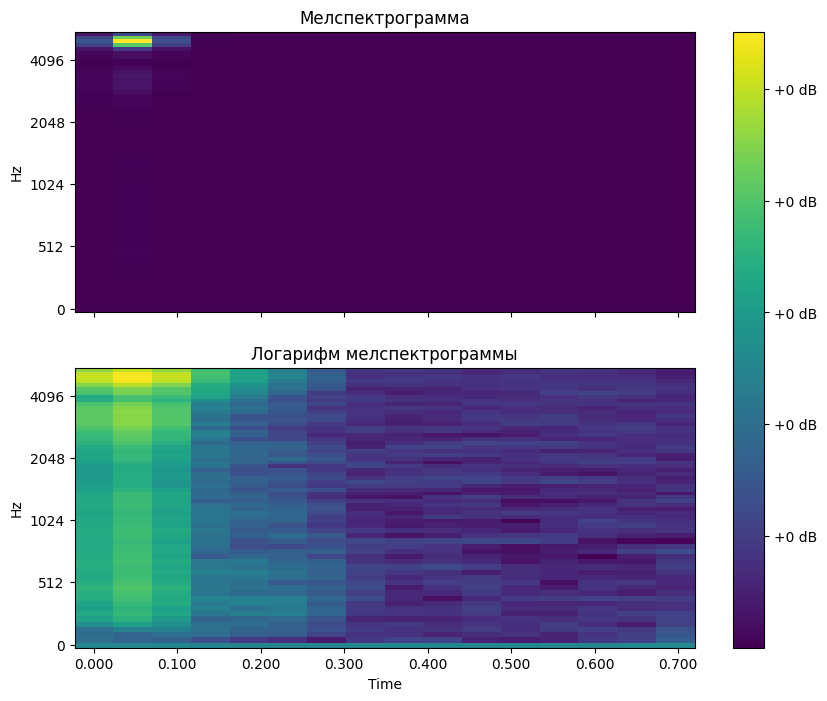

In [ ]:
wav_data, sr = librosa.load(df.loc[0, "fname"], sr=sample_rate)

mel_spec = F_lib.melspectrogram(y=wav_data, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, fmax=sample_rate // 2)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
cmap = "viridis"

img1 = librosa.display.specshow(
    mel_spec,
    sr=sr,
    fmax=sr // 2,
    ax=ax_top,
    x_axis="time",
    y_axis="mel",
    cmap=cmap,
)
ax_top.set(title="Мелспектрограмма")
ax_top.label_outer()

D = librosa.power_to_db(mel_spec, ref=np.max)
img2 = librosa.display.specshow(
    D,
    sr=sr,
    fmax=sr // 2,
    ax=ax_bottom,
    x_axis="time",
    y_axis="mel",
    cmap=cmap,
)
ax_bottom.set(title="Логарифм мелспектрограммы")
ax_bottom.label_outer()

fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.show()

display(Audio(wav_data, rate=sr))

## Извлечение признаков

In [ ]:
class SetType(Enum):
    """Set type"""

    TRAIN = 1
    TEST = 2
    DEV = 3

In [ ]:
label2id = {label: i for i, label in enumerate(df.label.unique())}
id2label = {i: label for label, i in label2id.items()}

## Алгоритм детектирования

### Подготовительный этап

In [ ]:
device = device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
cpu_count = os.cpu_count()

num_workers = cpu_count if device != "cpu" else 0
num_workers, cpu_count

(2, 2)

#### Добиваемся максимальной воспроизводимости
Согласно данному мануалу: https://pytorch.org/docs/stable/notes/randomness.html

In [ ]:
def set_random_state(random_state: int = 0) -> NoReturn:
    """Initialize random generators.

    Parameters
    ==========
    random_state : int = 0
        Determines random number generation for centroid initialization.
        Use an int to make the randomness deterministic.
    """
    torch.manual_seed(random_state)
    random.seed(random_state)
    np.random.seed(random_state)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        torch.cuda.manual_seed(random_state)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [ ]:
random_state = 42

In [ ]:
set_random_state(random_state)

In [ ]:
torch.use_deterministic_algorithms(True)

In [ ]:
%env CUBLAS_WORKSPACE_CONFIG=:4096:8
%env PYTHONHASHSEED=42

env: CUBLAS_WORKSPACE_CONFIG=:4096:8
env: PYTHONHASHSEED=42


### Архитектура нейронной сети

In [ ]:
class DummyNetwork(nn.Module):
    """Neural network base architecture"""

    def __init__(self, n_classes: int) -> None:
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=5, stride=(2, 2), device=device)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3, stride=(1, 1), device=device)
        self.conv3 = nn.Conv2d(in_channels=96, out_channels=64, kernel_size=3, stride=(1, 1), device=device)

        self.mp = nn.MaxPool2d(kernel_size=(2, 2), stride=(1, 1))

        self.dropout1 = nn.Dropout(p=0.3)
        self.dropout2 = nn.Dropout(p=0.3)
        self.dropout3 = nn.Dropout(p=0.3)

        self.bn1 = nn.BatchNorm2d(num_features=64, device=device)
        self.bn2 = nn.BatchNorm2d(num_features=96, device=device)
        self.bn3 = nn.BatchNorm2d(num_features=64, device=device)

        self.flat = nn.Flatten()

        # 33856 - должно соответствовать форме self.flat
        self.fc1 = nn.Linear(33856, n_classes, device=device)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout3(x)

        x = self.flat(x)

        # здесь можно еще добавить полносвязный слой или слои

        return self.fc1(x)

In [ ]:
set_random_state(random_state)
random_input = torch.randn(1, 1, 64, 64, requires_grad=True, device=device)

print(f"Исходный тензор {list(random_input.shape)}:")
pprint(random_input)

network = DummyNetwork(len(label2id))

output = network(random_input)

print(f"\nТензор на выходе нейронной сети {list(output.shape)}:")
pprint(output)

Исходный тензор [1, 1, 64, 64]:
tensor([[[[ 0.1940,  2.1614, -0.1721,  ..., -0.8146,  0.2502, -0.4273],
          [ 1.1044, -1.1028,  0.5543,  ..., -1.2072, -0.2438, -0.6784],
          [ 0.1973,  0.9782, -0.0287,  ..., -0.1266, -0.4321, -1.3943],
          ...,
          [-1.1998,  0.5818, -0.7198,  ..., -0.6079, -1.8145,  0.2807],
          [-0.0970,  0.9319, -0.4393,  ..., -0.1155, -0.0528,  1.1175],
          [ 3.0098,  1.3304, -1.1632,  ...,  0.1124,  0.2769, -1.2535]]]],
       device='cuda:0', requires_grad=True)

Тензор на выходе нейронной сети [1, 41]:
tensor([[-0.0437, -0.6455,  0.1273,  0.9486, -0.8313,  0.8500,  0.1742, -0.0384,
          0.0782, -0.9897,  0.4222, -0.0865, -0.6966,  1.0091,  1.0284,  0.4896,
          2.2631,  1.4351, -1.2141, -0.2496, -0.6252,  0.4495,  0.6215, -0.5325,
          0.4246,  0.3917,  1.0390, -0.3208,  0.2416,  1.5850, -1.0630,  1.2164,
         -2.0217, -0.4829,  0.4148,  0.4027,  0.2401,  1.1255, -0.9951, -1.2362,
         -0.8311]], device=

### Шаг оптимизации

In [ ]:
set_random_state(random_state)


# choose loss function
criterion = nn.CrossEntropyLoss()

# choose and tune optimizer
optimizer = optim.SGD(network.parameters(), lr=0.001)
optimizer.zero_grad()

random_input = torch.randn(3, 1, 64, 64, requires_grad=True, device=device)
print(f"Тензор на входе сети {list(random_input.shape)}:")
pprint(random_input)

output = network(random_input)
print(f"\nТензор на выходе сети {list(output.shape)}:")
pprint(output)

target = torch.randint(5, (3,), dtype=torch.long, device=device)
print(f"\nТензор с целевыми значениями {list(target.shape)}:")
pprint(target)

loss = criterion(output, target)
print("\nЗначение функции потерь:", loss.item())

# backpropagation
loss.backward()

# next step
optimizer.step()

Тензор на входе сети [3, 1, 64, 64]:
tensor([[[[ 0.1940,  2.1614, -0.1721,  ..., -0.8146,  0.2502, -0.4273],
          [ 1.1044, -1.1028,  0.5543,  ..., -1.2072, -0.2438, -0.6784],
          [ 0.1973,  0.9782, -0.0287,  ..., -0.1266, -0.4321, -1.3943],
          ...,
          [-1.1998,  0.5818, -0.7198,  ..., -0.6079, -1.8145,  0.2807],
          [-0.0970,  0.9319, -0.4393,  ..., -0.1155, -0.0528,  1.1175],
          [ 3.0098,  1.3304, -1.1632,  ...,  0.1124,  0.2769, -1.2535]]],


        [[[ 1.1346, -0.6329, -0.9147,  ..., -1.5122, -1.1374,  0.7628],
          [ 0.9661, -0.0587, -0.2129,  ...,  1.2377,  0.5842,  1.6728],
          [ 0.7942,  0.3131, -0.3607,  ...,  0.1261, -0.1309,  2.0342],
          ...,
          [-0.3319,  0.8590,  0.7535,  ..., -1.2910, -0.3644,  0.9805],
          [-0.5130,  0.6719, -0.1551,  ..., -0.4551, -0.1417, -1.2772],
          [-0.4063,  0.0820,  0.8311,  ..., -1.0449,  1.5397, -2.0042]]],


        [[[-0.5852, -0.9346,  0.9684,  ...,  0.5966, -1.6748,

### Обучение нейронной сети

#### Загрузка ранее извлеченных признаков и подготовка данных для обучения

In [ ]:
def dummy_split(pathes: list[Path], labels: list[int], validation_set_size: int = 800) -> tuple:
    x_val = []
    y_val = []

    x_tr = []
    y_tr = []

    for i, (path, label) in enumerate(zip(pathes, labels)):
        if i < validation_set_size:
            x_val.append(path)
            y_val.append(label)
        else:
            x_tr.append(path)
            y_tr.append(label)

    print(f"""
    Train set:
        x.shape: {len(x_tr)}
        y.shape: {len(y_tr)}

    Validation set:
        x.shape: {len(x_val)}
        y.shape: {len(y_val)}
    """)
    return x_tr, x_val, y_tr, y_val


def strat_split(pathes: list[Path], labels: list[int], validation_set_size: int = 800) -> tuple:
    x_tr, x_val, y_tr, y_val = train_test_split(
        pathes,
        labels,
        test_size=validation_set_size,
        stratify=labels,
        random_state=random_state,
    )
    print(f"""
    Train set:
        x.shape: {len(x_tr)}
        y.shape: {len(y_tr)}

    Validation set:
        x.shape: {len(x_val)}
        y.shape: {len(y_val)}
    """)
    return x_tr, x_val, y_tr, y_val

In [ ]:
class EventDetectionDataset(Dataset):
    def __init__(
        self,
        x: list[Path],
        y: list[str] | None = None,
        N: int = 64,
        set_type: SetType = SetType.TEST,
        sr: int = 11025,
    ) -> None:
        self.x = x
        self.y = y
        self.N = N  # размер во времени (можно увеличить, должно стать лучше)
        self.sr = sr
        self.set_type = set_type
        self.prepare()

    def __len__(self) -> int:
        return len(self.x)

    def __getitem__(self, idx) -> tuple:
        # добавить сюда prepare_shape()
        if self.labels is not None:
            return torch.tensor(self.prepare_shape(self.features[idx])), torch.tensor(self.labels[idx])

        return torch.tensor(self.prepare_shape(self.features[idx]), device=device), None

    def prepare(self) -> None:
        self.features, self.labels = self.extract_log_mel_feats()

    def prepare_shape(self, feature) -> np.ndarray:
        tmp = feature
        while tmp.shape[1] < self.N:
            # можно попробовать сделать np.pad для коротких файлов, вместо повторения до необходимой длины
            tmp = np.hstack((tmp, tmp))
        # случайный сдвиг должен улучшить результат (для этого нужно функцию перенести в EventDetectionDataset)
        return tmp[np.newaxis, :, : self.N]

    def extract_log_mel_feats(
        self,
        n_fft: int = 1024,
        hop_length: int = n_fft // 4,
        n_mels: int = 64,
    ) -> tuple[list, list | None]:
        feats = []

        if self.set_type == SetType.TRAIN or self.set_type == SetType.DEV:
            labels = []

            for file_name, label in tqdm(zip(self.x, self.y)):
                wav_data, sr = librosa.load(file_name, sr=self.sr)
                mel_spec = F_lib.melspectrogram(
                    y=wav_data,
                    n_fft=n_fft,
                    hop_length=hop_length,
                    n_mels=n_mels,
                    fmax=sr // 2,
                )
                log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
                feats.append(log_mel_spec)
                labels.append(label)
            return feats, labels
        for file_name in tqdm(self.x):
            wav_data, sr = librosa.load(file_name, sr=self.sr)
            if len(wav_data) == 0:
                wav_data = np.zeros(sr)
            mel_spec = F_lib.melspectrogram(
                y=wav_data,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmax=sr // 2,
            )
            log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
            feats.append(log_mel_spec)

        return feats, None

In [ ]:
labels = df["label"].apply(lambda x: label2id[x]).to_list()
x_tr, x_val, y_tr, y_val = dummy_split(df["fname"].to_list(), labels)
train_dset = EventDetectionDataset(x_tr, y_tr, set_type=SetType.TRAIN)
val_dset = EventDetectionDataset(x_val, y_val, set_type=SetType.DEV)


    Train set:
        x.shape: 4883
        y.shape: 4883

    Validation set:
        x.shape: 800
        y.shape: 800
    


4883it [01:35, 51.31it/s]
800it [00:14, 55.47it/s]


In [ ]:
set_random_state(random_state)

sample_x, sample_y = random.choice(val_dset)

sample_y.item(), id2label[sample_y.item()]

(19, 'Cough')

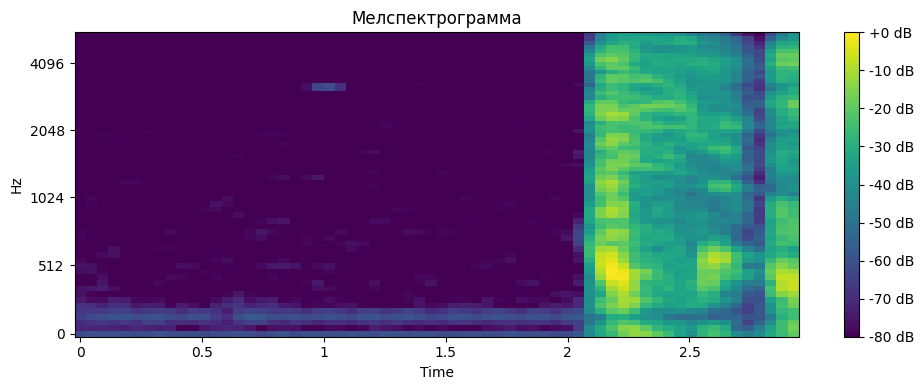

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
cmap = "viridis"

img = librosa.display.specshow(
    sample_x[0].numpy(force=True),
    sr=sample_rate,
    fmax=sample_rate // 2,
    ax=ax,
    x_axis="time",
    y_axis="mel",
    cmap=cmap,
)
ax.set(title="Мелспектрограмма")
ax.label_outer()

fig.colorbar(img, ax=ax, format="%+2.f dB")
plt.tight_layout()
plt.show()

In [ ]:
train_loader = DataLoader(
    train_dset,
    batch_size=41,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available() and num_workers > 1,
)
val_loader = DataLoader(
    val_dset,
    batch_size=41,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available() and num_workers > 1,
)

epoch #1


[train] mean loss: 3.4630783836046857
[train] accuracy:  0.1245136186770428


[val] mean loss:   3.5618746161460875
[val] accuracy:    0.06625

epoch #2


[train] mean loss: 2.917128537098567
[train] accuracy:  0.21912758550071676


[val] mean loss:   3.344740116596222
[val] accuracy:    0.12875

epoch #3


...

[val] mean loss:   2.2414600551128387
[val] accuracy:    0.39

epoch #49


[train] mean loss: 0.9179853732387225
[train] accuracy:  0.7491296334220766


[val] mean loss:   2.1497178614139556
[val] accuracy:    0.43125

epoch #50


[train] mean loss: 0.9077589472134908
[train] accuracy:  0.7618267458529593


[val] mean loss:   2.6975289821624755
[val] accuracy:    0.32125

Execution time: 88.04 seconds


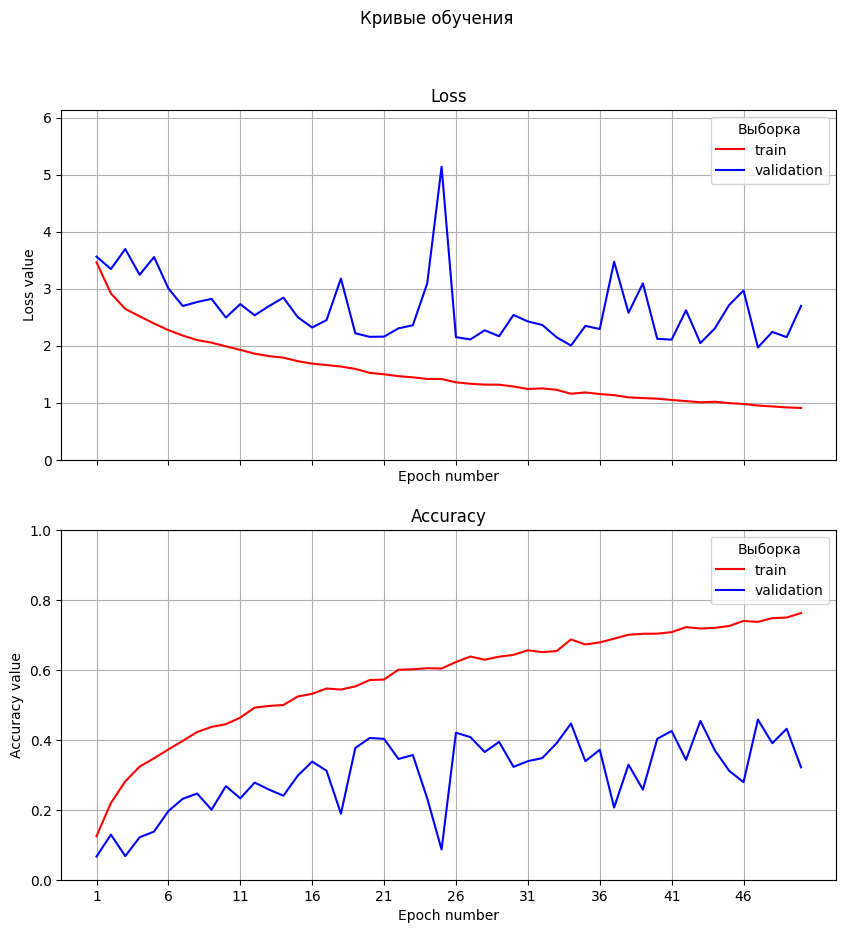

In [ ]:
def train(
    network,
    optimizer,
    train_loader,
    val_loader,
    n_epoch: int = 50,
    random_state: int = random_state,
    weight: torch.Tensor | None = None,
) -> None:
    start_time = time.time()

    set_random_state(random_state)

    criterion = nn.CrossEntropyLoss()

    train_loss = []
    val_loss = []

    train_acc = []
    val_acc = []

    for e in range(n_epoch):
        print(f"epoch #{e + 1}")

        # train
        network.train()
        loss_list = []
        outputs = []
        targets = []
        for sample_batched in tqdm(train_loader, desc="Training", leave=False):
            x, y = sample_batched
            x = x.to(device, non_blocking=device != "cpu")
            y = y.to(device, non_blocking=device != "cpu")
            optimizer.zero_grad()

            output = network(x)
            outputs.append(output.argmax(axis=1))

            target = y
            targets.append(target)

            loss = criterion(output, target.long())
            loss_list.append(loss.item())
            loss.backward()
            optimizer.step()

        y_true = torch.hstack(targets).numpy(force=True)
        y_pred = torch.hstack(outputs).numpy(force=True)
        acc = accuracy_score(y_true, y_pred)

        train_loss.append(np.mean(loss_list))
        train_acc.append(acc)

        print(f"[train] mean loss: {train_loss[-1]}")
        print(f"[train] accuracy:  {acc}")

        loss_list = []
        outputs = []
        targets = []
        network.eval()
        with torch.no_grad():
            for sample_batched in tqdm(val_loader, desc="Validation", leave=False):
                x, y = sample_batched
                x = x.to(device, non_blocking=device != "cpu")
                y = y.to(device, non_blocking=device != "cpu")

                output = network(x)
                outputs.append(output.argmax(axis=1))

                target = y
                targets.append(target)

                loss = criterion(output, target.long())
                loss_list.append(loss.item())

            y_true = torch.hstack(targets).numpy(force=True)
            y_pred = torch.hstack(outputs).numpy(force=True)
            acc = accuracy_score(y_true, y_pred)

            val_loss.append(np.mean(loss_list))
            val_acc.append(acc)

            print(f"[val] mean loss:   {val_loss[-1]}")
            print(f"[val] accuracy:    {acc}", end="\n\n")

    print(f"Execution time: {(time.time() - start_time):.2f} seconds")
    return train_loss, val_loss, train_acc, val_acc


def plot_metrics(n_epoch, train_loss, val_loss, train_acc, val_acc) -> None:
    epochs = range(1, n_epoch + 1)

    fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

    xticks = range(1, n_epoch + 1, n_epoch // 10) if n_epoch > 10 else epochs

    # draw loss
    ax_top.plot(epochs, train_loss, "r", label="train")
    ax_top.plot(epochs, val_loss, "b", label="validation")

    ax_top.set(
        title="Loss",
        xlabel="Epoch number",
        ylabel="Loss value",
        ylim=[0, max(max(train_loss), max(val_loss)) + 1],
    )
    ax_top.legend(
        title="Выборка",
    )
    ax_top.grid()

    # draw accuracy
    ax_bottom.plot(epochs, train_acc, "r", label="train")
    ax_bottom.plot(epochs, val_acc, "b", label="validation")

    ax_bottom.set(
        title="Accuracy",
        xlabel="Epoch number",
        ylabel="Accuracy value",
        xticks=xticks,
        ylim=[0, 1],
    )
    ax_bottom.legend(
        title="Выборка",
    )
    ax_bottom.grid()

    fig.suptitle("Кривые обучения")

    plt.show()


network = DummyNetwork(len(label2id)).to(device)
optimizer = optim.SGD(network.parameters(), lr=0.001)
n_epoch = 50

train_loss, val_loss, train_acc, val_acc = train(
    network,
    optimizer,
    train_loader,
    val_loader,
    n_epoch,
)
plot_metrics(n_epoch, train_loss, val_loss, train_acc, val_acc)

# Экспы

## Архитектура

In [ ]:
class ConvBnReLU(nn.Module):
    def __init__(
        self,
        in_ch: int,
        out_ch: int,
        kernel_size: int = 5,
        stride: tuple[int, ...] = (2, 2),
        padding: int = 0,
    ) -> None:
        super().__init__()
        self.module = nn.Sequential(
            nn.Conv2d(
                in_channels=in_ch,
                out_channels=out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.module(features)


class ResConv(nn.Module):
    def __init__(self, n_classes: int, hid_dim: int = 34992) -> None:
        super().__init__()
        self.block1 = ConvBnReLU(1, 64, 5, (2, 2))
        self.block2 = ConvBnReLU(64, 64, 3, (1, 1), padding=1)
        self.block3 = ConvBnReLU(64, 64, 3, (1, 1), padding=1)
        self.block4 = ConvBnReLU(64, 64, 3, (1, 1), padding=1)
        self.block5 = ConvBnReLU(64, 64, 3, (1, 1), padding=1)
        self.block6 = ConvBnReLU(64, 48, 3, (1, 1))

        self.drop1 = nn.Dropout()
        self.drop2 = nn.Dropout()
        self.drop3 = nn.Dropout()

        self.avg_pool = nn.AvgPool2d(kernel_size=(2, 2), stride=(1, 1))
        self.flat = nn.Flatten()

        self.rms1 = nn.RMSNorm(8192)
        self.rms2 = nn.RMSNorm(512)
        self.act = nn.GELU()

        self.fc1 = nn.Linear(hid_dim, 8192)
        self.fc2 = nn.Linear(8192, 512)
        self.fc3 = nn.Linear(512, n_classes)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        out = self.block1(features)

        # residual
        out = self.block2(out) + out
        out = self.drop1(self.block3(out)) + out
        out = self.block4(out) + out
        out = self.drop2(self.block5(out)) + out

        out = self.block6(out)
        out = self.avg_pool(out)
        out = self.flat(out)

        out = self.drop3(self.act(self.rms1(self.fc1(out))))
        out = self.act(self.rms2(self.fc2(out)))
        return self.fc3(out)

epoch #1


[train] mean loss: 3.4196701725323995
[train] accuracy:  0.12963342207659226


[val] mean loss:   2.928185296058655
[val] accuracy:    0.24

epoch #2


[train] mean loss: 2.965260561307271
[train] accuracy:  0.24534097890641


[val] mean loss:   2.670506739616394
[val] accuracy:    0.2725

epoch #3


...

[val] mean loss:   1.4799555331468581
[val] accuracy:    0.60375

epoch #49


[train] mean loss: 0.20687810269494852
[train] accuracy:  0.9891460167929551


[val] mean loss:   1.5213834196329117
[val] accuracy:    0.58625

epoch #50


[train] mean loss: 0.20222956798970698
[train] accuracy:  0.9920131066967028


[val] mean loss:   1.595753651857376
[val] accuracy:    0.585

Execution time: 516.87 seconds


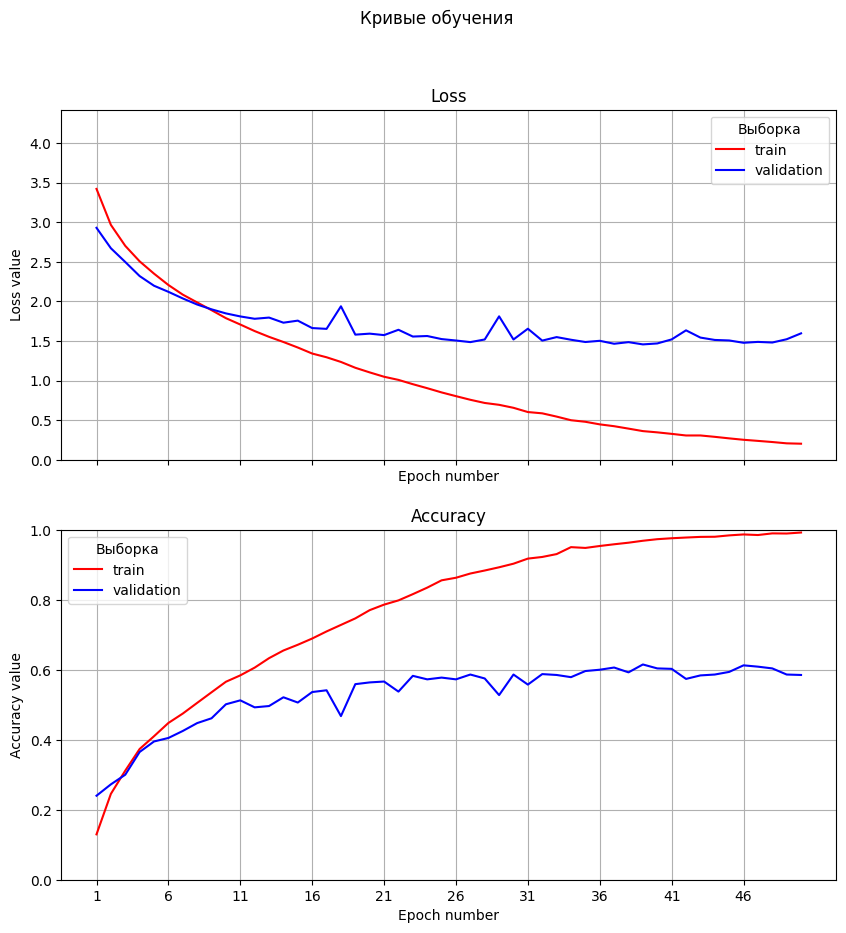

In [ ]:
network = ResConv(len(label2id)).to(device)
optimizer = optim.SGD(network.parameters(), lr=0.001)
n_epoch = 50

train_loss, val_loss, train_acc, val_acc = train(
    network,
    optimizer,
    train_loader,
    val_loader,
    n_epoch,
)
plot_metrics(n_epoch, train_loss, val_loss, train_acc, val_acc)

## Разбиение со стратификацией


    Train set:
        x.shape: 4883
        y.shape: 4883

    Validation set:
        x.shape: 800
        y.shape: 800
    


4883it [01:11, 68.22it/s]
800it [00:13, 61.46it/s]


epoch #1


[train] mean loss: 3.4186236123243967
[train] accuracy:  0.13331968052426788


[val] mean loss:   3.023570704460144
[val] accuracy:    0.22

epoch #2


...

[val] mean loss:   1.6157626450061797
[val] accuracy:    0.57

epoch #49


[train] mean loss: 0.2110010529557864
[train] accuracy:  0.990579561744829


[val] mean loss:   1.7421727180480957
[val] accuracy:    0.5425

epoch #50


[train] mean loss: 0.2053509870544076
[train] accuracy:  0.9889412246569732


[val] mean loss:   1.609566468000412
[val] accuracy:    0.5725

Execution time: 515.03 seconds


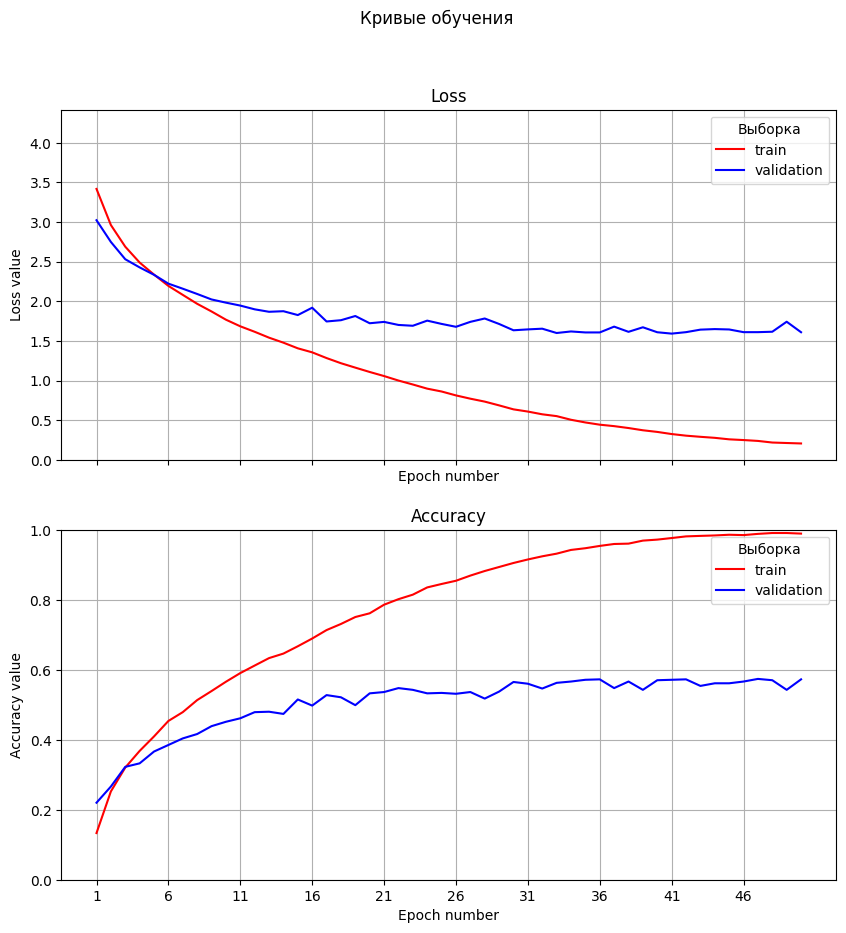

In [ ]:
x_tr, x_val, y_tr, y_val = strat_split(df["fname"].to_list(), labels)
train_dset = EventDetectionDataset(x_tr, y_tr, set_type=SetType.TRAIN)
val_dset = EventDetectionDataset(x_val, y_val, set_type=SetType.DEV)

train_loader = DataLoader(
    train_dset,
    batch_size=41,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available() and num_workers > 1,
)
val_loader = DataLoader(
    val_dset,
    batch_size=41,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available() and num_workers > 1,
)

network = ResConv(len(label2id)).to(device)
optimizer = optim.SGD(network.parameters(), lr=0.001)
n_epoch = 50

train_loss, val_loss, train_acc, val_acc = train(
    network,
    optimizer,
    train_loader,
    val_loader,
    n_epoch,
)
plot_metrics(n_epoch, train_loss, val_loss, train_acc, val_acc)

## Увеличение частоты дискретизации и количества отсчётов в спектрограмме

epoch #1


[train] mean loss: 3.221102201938629
[train] accuracy:  0.17857874257628506


[val] mean loss:   2.868064796924591
[val] accuracy:    0.20375

epoch #2


[train] mean loss: 2.718206614255905
[train] accuracy:  0.2979725578537784


[val] mean loss:   2.602221190929413
[val] accuracy:    0.27

epoch #3


...

[val] mean loss:   1.5097727000713348
[val] accuracy:    0.60625

epoch #49


[train] mean loss: 0.08812089997033277
[train] accuracy:  0.9983616629121441


[val] mean loss:   1.5160834193229675
[val] accuracy:    0.60125

epoch #50


[train] mean loss: 0.08450627094134688
[train] accuracy:  0.9981568707761622


[val] mean loss:   1.5249646067619325
[val] accuracy:    0.60875

Execution time: 1085.50 seconds


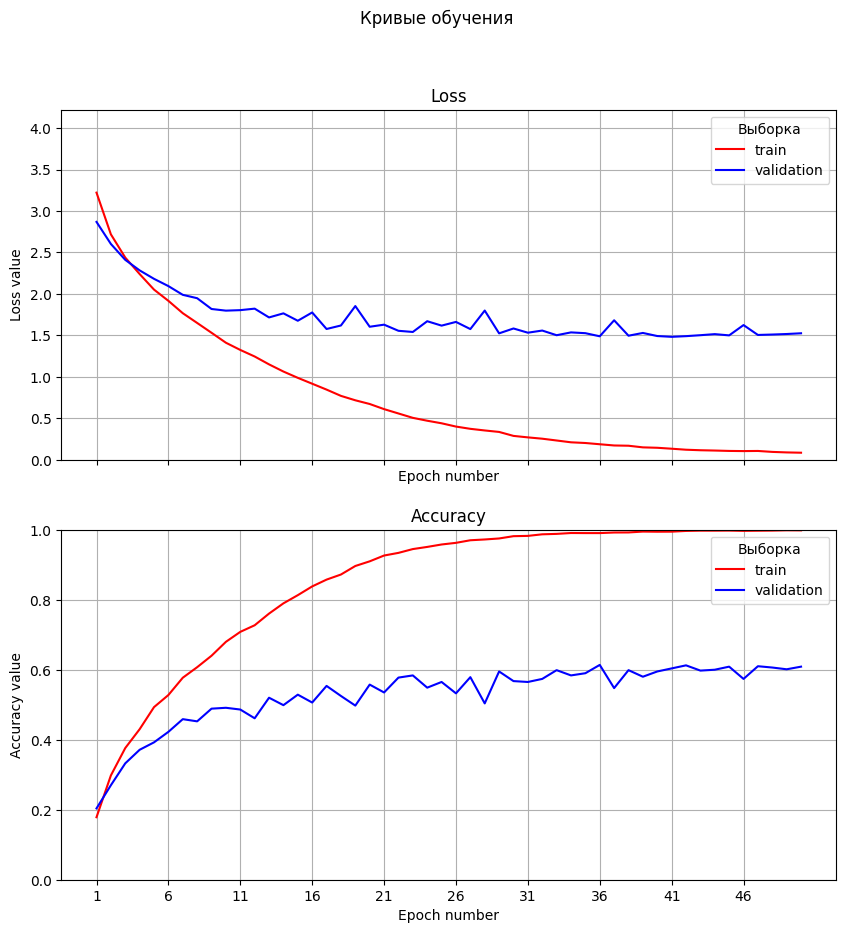

In [ ]:
train_dset = EventDetectionDataset(x_tr, y_tr, set_type=SetType.TRAIN, N=128, sr=16_000)
val_dset = EventDetectionDataset(x_val, y_val, set_type=SetType.DEV, N=128, sr=16_000)

train_loader = DataLoader(
    train_dset,
    batch_size=41,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available() and num_workers > 1,
)
val_loader = DataLoader(
    val_dset,
    batch_size=41,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available() and num_workers > 1,
)

network = ResConv(len(label2id), 76464).to(device)
optimizer = optim.SGD(network.parameters(), lr=0.001)
n_epoch = 50

train_loss, val_loss, train_acc, val_acc = train(
    network,
    optimizer,
    train_loader,
    val_loader,
    n_epoch,
)
plot_metrics(n_epoch, train_loss, val_loss, train_acc, val_acc)

## Momentum

epoch #1


[train] mean loss: 2.9918297211329143
[train] accuracy:  0.2056113045259062


[val] mean loss:   2.518412673473358
[val] accuracy:    0.2875

epoch #2


[train] mean loss: 2.247216405471166
[train] accuracy:  0.3907433954536146


[val] mean loss:   2.0802283108234407
[val] accuracy:    0.41

epoch #3


...

[val] mean loss:   1.7889494955539704
[val] accuracy:    0.60875

epoch #49


[train] mean loss: 0.004915764413696403
[train] accuracy:  0.9995904157280361


[val] mean loss:   1.7825856328010559
[val] accuracy:    0.6

epoch #50


[train] mean loss: 0.004610178056949129
[train] accuracy:  0.999795207864018


[val] mean loss:   1.7877186238765717
[val] accuracy:    0.59875

Execution time: 1565.68 seconds


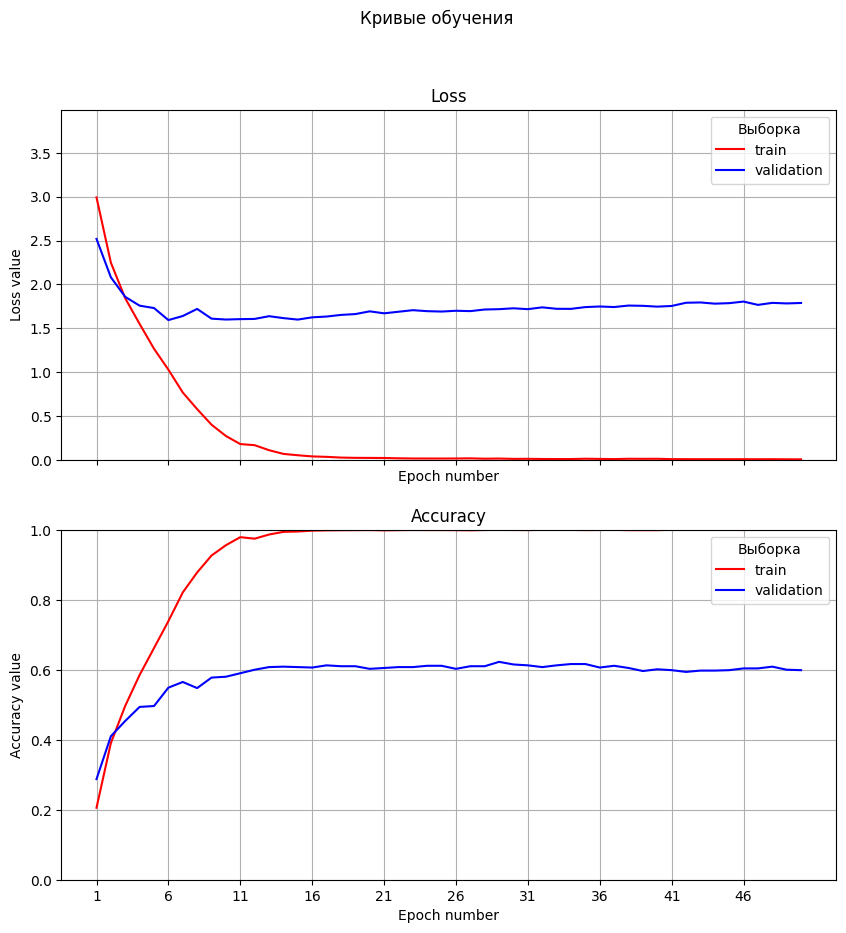

In [ ]:
network = ResConv(len(label2id), 76464).to(device)
optimizer = optim.SGD(network.parameters(), lr=0.001, momentum=0.9, fused=True)
n_epoch = 50

train_loss, val_loss, train_acc, val_acc = train(
    network,
    optimizer,
    train_loader,
    val_loader,
    n_epoch,
)
plot_metrics(n_epoch, train_loss, val_loss, train_acc, val_acc)

## Веса классов (уменьшим число эпох, так как с моментом мы достигаем предела быстрее)

epoch #1


[train] mean loss: 3.121217582623164
[train] accuracy:  0.188613557239402


[val] mean loss:   2.604564380645752
[val] accuracy:    0.26875

epoch #2


[train] mean loss: 2.3227705707152686
[train] accuracy:  0.3708785582633627


[val] mean loss:   2.1186108112335207
[val] accuracy:    0.40875

epoch #3


...

[val] mean loss:   1.7733497023582458
[val] accuracy:    0.6075

epoch #24


[train] mean loss: 0.01612278742250055
[train] accuracy:  0.9989760393200902


[val] mean loss:   1.743256837129593
[val] accuracy:    0.62

epoch #25


[train] mean loss: 0.013862740601568172
[train] accuracy:  0.9993856235920541


[val] mean loss:   1.7541388154029847
[val] accuracy:    0.61125

Execution time: 782.67 seconds


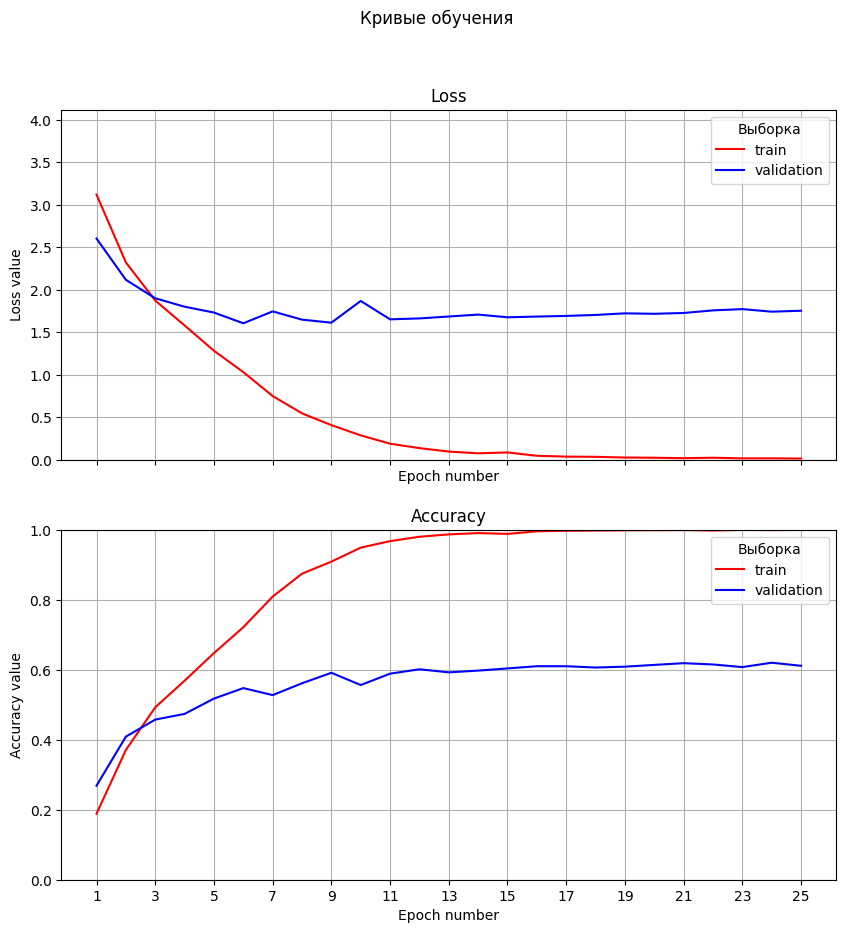

In [ ]:
weights = torch.tensor(
    compute_class_weight("balanced", classes=df.label.unique(), y=df.label.to_numpy()), dtype=torch.float, device=device
)
network = ResConv(len(label2id), 76464).to(device)
optimizer = optim.SGD(network.parameters(), lr=0.001, momentum=0.9, fused=True)
n_epoch = 25

train_loss, val_loss, train_acc, val_acc = train(
    network,
    optimizer,
    train_loader,
    val_loader,
    n_epoch,
    weight=weights,
)
plot_metrics(n_epoch, train_loss, val_loss, train_acc, val_acc)

# Выводы

Новая архитектура:
- Повысили точность c 0.4 до 0.6
- Сделали обучение более плавным
- Увеличили сильно вычислительную сложность и время работы

Новое разбиение:
- Суммарная точность никак не изменилась

Использование более длинных кусков аудио:
- Незначительные прирост

Использование SGD с моментумом:
- Быстрее дошли до точности 0.61, побрыкались на 0.62, но так и не смогли приблизиться к 0.65

Взвешенная кросс-энтропия:
- Чуть ухудшило. Видимо, из-за чуть другого баланса классов внутри батча без весов получается лучше